# Sample 3: interpolation bias on a rigid sub-pixel translation

**Dataset.** DIC Challenge 1.0, Sample 3 (Reu et al., 2018): an FFT-shifted speckle image translated by 0.1 px per frame from 0.0 to 1.0 px in *x* and *y*. The fractional offset walks through a full period, so interpolation bias appears as a systematic, shift-dependent error.

**Ground truth** is encoded in each filename (`Sample3-003 X0.30 Y0.30 N2 C0 R0.tif`). The field is a uniform translation, so no Eulerian→Lagrangian correction is needed.

**What this establishes for Chapter 5**
1. A reproduction of Reu et al.'s Fig. 21 with the engine's default configuration.
2. A comparison of the three interpolants: Lanczos-4 (`8tap`), bicubic spline, biquintic B-spline.
3. The error budget: the peak bias against the within-frame dispersion, which is the random error, with the pooled RMSE and MAE as measures of the total error.

Every run goes through the CLI (`python -m cli.main run --set ...`); the exact command is saved as `command.txt` beside each result, so every number here is re-runnable.

In [1]:
import os
import sys
from pathlib import Path

# The notebook lives in notebooks/; validation/ and cli/ live at the repository root.
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

# Environment variables win, so another machine or a CI job runs the notebook unchanged.
CHALLENGE = Path(os.environ.get("DIC_CHALLENGE", "~/Documents/dicsamples/2D-Challenge1")).expanduser()
RESULTS = Path(os.environ.get("DIC_RESULTS", "~/Documents/dicresults-clean")).expanduser()

# True re-runs every configuration even when its output already exists.
FORCE = False

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from validation.runner import Dataset, SweepPoint, expand_grid, score_run
from validation.workflow import run_point, run_quality, write_base_config
from validation.truth import FilenameShiftTruth

print("repo    :", REPO)
print("data    :", CHALLENGE)
print("results :", RESULTS)

## Configuration

Matches the settings inset of Reu's Fig. 21: subset 31, step 7, strain window 5, ZNSSD. Two stated
differences from Reu:

- **Interpolant.** Reu used the vendor "Optimised 8-Tap" filter, a proprietary bias-minimised kernel. The
  engine's `8tap` is plain normalised Lanczos-4: same support width, different coefficients.
- **Search window, 41 px.** Reu does not report one; it only needs to exceed the subset plus the largest
  shift (1 px).

In [2]:
SAMPLE_DIR = CHALLENGE / "Sample3"
assert SAMPLE_DIR.is_dir(), f"not found: {SAMPLE_DIR}"

BASE = {
    "session": {
        "image_dir": str(SAMPLE_DIR),
        "mode": "all",
        "reference_frame": "Sample3 Reference.tif",  # explicit, not by sort order
    },
    "setup": {"subset_size": 31, "step_size": 7},
    "correlation": {
        "search_size": 41,
        "correlation_mode": "spatial",
        "tracking_mode": "eulerian",
        "criterion_name": "znssd",
        "match_threshold": 0.6,
        "n_workers": 4,
        "search": {"method": "brute"},
        "refinement": {"method": "icgn", "shape_function": "affine"},
        "strain": {"method": "lagrange_q4", "strain_window": 5},
        "image_interpolation": {"method": "biquintic_spline"},
    },
}

config_path, runs_root = write_base_config(BASE, "sample03", RESULTS)
dataset = Dataset("Sample3", config_path, FilenameShiftTruth())
print("config:", config_path)


## Run and score

One run per interpolant. The engine's remaining interpolants are compared; the nearest-neighbour option
has been removed from the engine, since a zero-order kernel gives the IC-GN iteration no sub-pixel
information to converge on.

`run_quality` records, for each run, the valid rate over the nodes inside the ROI and the percentage of
valid nodes whose IC-GN iteration did not reach its tolerance. The engine flags such nodes but keeps them
when their score passes the threshold, so the percentage is reported rather than filtered.

In [3]:
INTERPOLANTS = ["8tap", "bicubic_spline", "biquintic_spline"]

rows, quality = [], []
for point in expand_grid(**{"correlation.image_interpolation.method": INTERPOLANTS}):
    outcome = run_point(dataset, runs_root, point, repo=REPO, force=FORCE)
    if not outcome.ok:
        continue
    interpolant = point.overrides["correlation.image_interpolation.method"]
    quality.append({"interpolant": interpolant, **run_quality(outcome.output_dir)})
    per_frame, pooled = score_run(outcome.output_dir, dataset)
    for r in (*per_frame, *pooled):
        rows.append({"interpolant": interpolant, "engine_seconds": outcome.engine_seconds, **r})

table = pd.DataFrame(rows)
table["shift_px"] = table.frame_name.str.extract(r"X(-?\d+\.\d+)", expand=False).astype(float)
per_frame = table[table.frame_index >= 0]
pooled = table[table.frame_index == -1]
quality = pd.DataFrame(quality).set_index("interpolant")

  84fa5d2dd9  reused  


  64d47b2367  reused  


  07fe8618e3  reused  


## Sanity checks

- **The zero-shift frame.** At zero shift every interpolating kernel samples the deformed image at integer
  positions, where all of them return the pixel values exactly. Whatever bias remains is therefore not
  interpolation: it is the effect of this one noise realisation, and it should be the same for every
  interpolant. It sets a floor: a difference in bias between two interpolants smaller than this is not
  resolved by this dataset.
- **The valid rate** over the nodes inside the ROI should be high and constant across interpolants. Nodes
  within half a search window of the image edge fail the bounds check, so it is below 100 %.
- **The non-converged percentage** should be near zero on these rigid-translation images.

In [4]:
zero = per_frame[np.isclose(per_frame.shift_px, 0.0)]
zero_bias = zero.pivot_table(index="interpolant", columns="component", values="bias")
NOISE_FLOOR = float(zero_bias.abs().to_numpy().max())
print("zero-shift bias (px):")
print(zero_bias.round(6))
print(f"\nnoise-realisation floor for bias comparisons: {NOISE_FLOOR:.5f} px")
print("\nrun quality:")
print(quality.round(4))

zero-shift bias (px):
component                u         v
interpolant                         
8tap             -0.000379 -0.000016
bicubic_spline   -0.000407 -0.000018
biquintic_spline -0.000403 -0.000020

noise-realisation floor for bias comparisons: 0.00041 px

run quality:
                  roi_nodes  valid_rate_roi  nonconverged_pct
interpolant                                                  
8tap                   4761          0.9712               0.0
bicubic_spline         4761          0.9712               0.0
biquintic_spline       4761          0.9712               0.0


## Reproduction of Reu et al. Fig. 21

Bias per imposed shift with ±1σ error bars (σ = dispersion of the error across nodes, as Reu plots).

**Sign convention.** `bias` here is *computed − truth*; Reu defines Δu = *commanded − DIC*, the negative.
`REU_SIGN = True` overlays directly on his figure. Read from his figure for scale: bias within about
±0.0012 px, error bars about ±0.004 px.

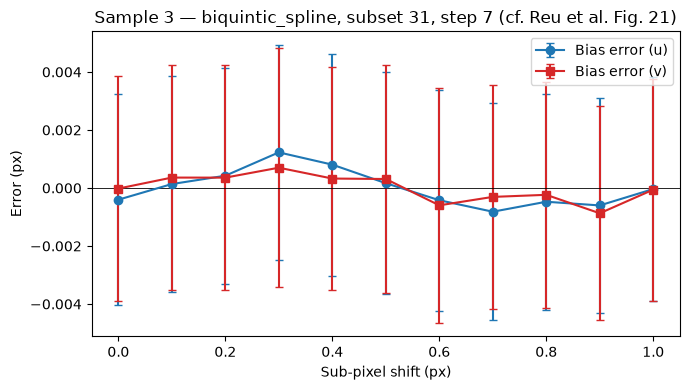

In [5]:
FIG21_INTERPOLANT = "biquintic_spline"   # the engine default
REU_SIGN = False
sign = -1.0 if REU_SIGN else 1.0

fig, ax = plt.subplots(figsize=(7, 4))
d = per_frame[per_frame.interpolant == FIG21_INTERPOLANT]
for component, marker, colour in (("u", "o", "tab:blue"), ("v", "s", "tab:red")):
    c = d[d.component == component].sort_values("shift_px")
    ax.errorbar(c.shift_px, sign * c.bias, yerr=c.dispersion, marker=marker,
                color=colour, capsize=3, label=f"Bias error ({component})")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("Sub-pixel shift (px)")
ax.set_ylabel("Error (px)")
ax.set_title(f"Sample 3 — {FIG21_INTERPOLANT}, subset 31, step 7 (cf. Reu et al. Fig. 21)")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS / "sample3_interpolant_bias_error.pdf", dpi=300)


## Interpolant comparison

Bias (top) is the systematic error an interpolant is responsible for; dispersion (bottom) is the random
part.

**Why Lanczos-4 is worst here.** Normalising the Lanczos weights fixes their sum but not their centroid:
at a fractional offset of 0.2 the weights' centroid sits at 0.214. On a locally linear intensity ramp (a
smooth speckle at pixel scale) the interpolant samples from ~0.014 px to one side, and the IC-GN converges
to a correspondingly shifted position. The error is positive below 0.5 and negative above, which is the
shape of its curve. B-splines reproduce polynomials exactly up to their degree, so they do not suffer this;
the quintic reproduces up to degree five, which is why it is the most robust across speckle sizes.

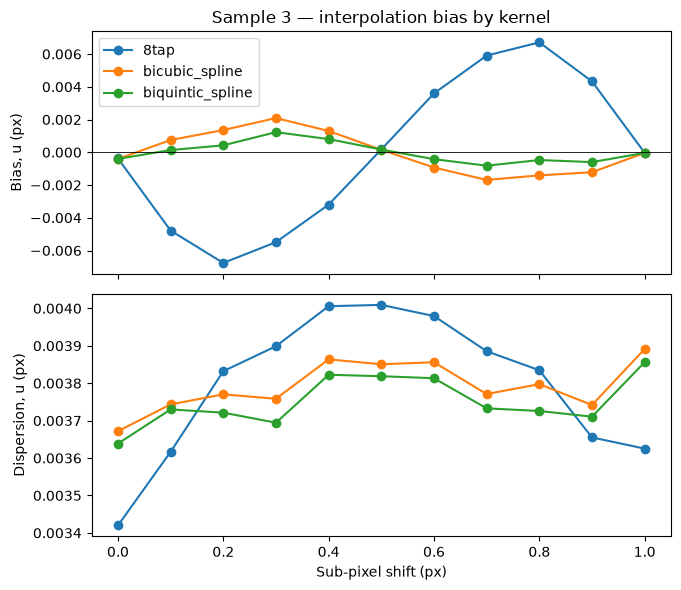

In [6]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
for interpolant, group in per_frame[per_frame.component == "u"].groupby("interpolant"):
    g = group.sort_values("shift_px")
    top.plot(g.shift_px, g.bias, marker="o", label=interpolant)
    bottom.plot(g.shift_px, g.dispersion, marker="o", label=interpolant)
top.axhline(0, color="k", lw=0.6)
top.set_ylabel("Bias, u (px)")
bottom.set_ylabel("Dispersion, u (px)")
bottom.set_xlabel("Sub-pixel shift (px)")
top.legend()
top.set_title("Sample 3 — interpolation bias by kernel")
fig.tight_layout()
fig.savefig(RESULTS / "sample3_interpolant_bias_dispersion.pdf", dpi=300)


## Error budget per interpolant

One row per interpolant and component, over all deformed frames.

**Pooled `bias` is not a useful summary.** The bias curve is antisymmetric about 0.5 px, so its mean is near zero for
every interpolant. The systematic error is summarised instead by `peak_bias` (largest per-frame |bias|);
`rmse_all_frames` and `mae` summarise total error, and `mae` is the Challenge's *e_u*.

**Two kinds of dispersion.**
- `dispersion_within` is the random error: each frame's standard deviation of the error across nodes,
  combined over frames as an RMS. The bias is constant within a frame, so it does not enter.
- `dispersion_all_frames` and `rmse_all_frames` pool every node of every frame, so they also contain the
  frame-to-frame variation of the bias: they measure the total scatter, not the random error alone.

The error bars of the Fig. 21 reproduction above are per-frame dispersions, consistent with
`dispersion_within`.

In [7]:
peak = (per_frame.assign(abs_bias=per_frame.bias.abs())
        .groupby(["interpolant", "component"]).abs_bias.max().rename("peak_bias"))
budget = (pooled.set_index(["interpolant", "component"])[["dispersion", "rmse", "mae"]]
          .join(peak)
          .rename(columns={"dispersion": "dispersion_all_frames", "rmse": "rmse_all_frames"}))
within = (per_frame.groupby(["interpolant", "component"]).dispersion
          .apply(lambda s: float(np.sqrt((s**2).mean()))).rename("dispersion_within"))
budget = budget.join(within)
budget["systematic_share"] = budget.peak_bias / budget.dispersion_within
budget["peak_over_floor"] = budget.peak_bias / NOISE_FLOOR
interpolants = budget.index.get_level_values("interpolant")
budget["valid_rate_roi"] = interpolants.map(quality.valid_rate_roi)
budget["nonconverged_pct"] = interpolants.map(quality.nonconverged_pct)
budget.round(5)

dispersion_all_frames  rmse_all_frames      mae  \
interpolant      component                                                    
8tap             u                        0.00587          0.00587  0.00480   
                 v                        0.00620          0.00620  0.00507   
bicubic_spline   u                        0.00398          0.00398  0.00314   
                 v                        0.00406          0.00406  0.00320   
biquintic_spline u                        0.00380          0.00380  0.00300   
                 v                        0.00392          0.00392  0.00309   

                            peak_bias  dispersion_within  systematic_share  \
interpolant      component                                                   
8tap             u            0.00676            0.00380           1.77858   
                 v            0.00716            0.00395           1.81187   
bicubic_spline   u            0.00209            0.00379           0.55141   
                 v            0.00145            0.00394           0.36771   
biquintic_spline u            0.00123            0.00375           0.32732   
                 v            0.00087            0.00390           0.22369   

                            peak_over_floor  valid_rate_roi  nonconverged_pct  
interpolant      component                                                     
8tap             u                 16.61291         0.97122               0.0  
                 v                 17.58836         0.97122               0.0  
bicubic_spline   u                  5.13953         0.97122               0.0  
                 v                  3.56124         0.97122               0.0  
biquintic_spline u                  3.01784         0.97122               0.0  
                 v                  2.14205         0.97122               0.0

`systematic_share` is peak bias as a fraction of the within-frame dispersion. Below about 0.5, the random error dominates:
the measurement is noise-limited and the interpolant is no longer the limiting error.

`peak_over_floor` compares the peak bias with the zero-shift floor. A ranking between two interpolants is
only supported where their peak biases differ by clearly more than the floor; within it, they are
indistinguishable on this dataset.

In [8]:
out = RESULTS / "sample03"
out.mkdir(parents=True, exist_ok=True)
table.to_csv(out / "sample03_per_frame.csv", index=False)
budget.to_csv(out / "sample03_error_budget.csv")
quality.to_csv(out / "sample03_run_quality.csv")
for f in ("sample03_per_frame.csv", "sample03_error_budget.csv", "sample03_run_quality.csv"):
    print("wrote", out / f)